In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from modelos.funcao import FuncaoMovimento
from metodos.bissecao import Bissecao
from metodos.newton import NewtonRaphson


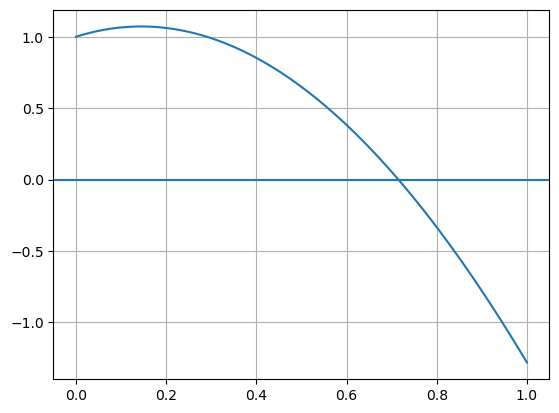

In [2]:
funcao = FuncaoMovimento(a=1)

x = np.linspace(0, 1, 100)
y = funcao.f(x)

plt.plot(x, y)
plt.axhline(0)
plt.grid()
plt.show()

Por que fazer isso?

Porque o trabalho fala em isolamento.

Para usar Bisseção, precisamos encontrar um intervalo onde:

- f(a) * f(b) < 0

Ou seja:

- num extremo a função é positiva;
- no outro extremo é negativa.

O gráfico mostra exatamente onde isso acontece.

In [3]:
print(funcao.f(0))
print(funcao.f(1))

1.0
-1.281718171540955


Logo:

$$ f(0)\cdot f(1) < 0 $$

porque:

$$ 1.0 \times (-1.2817) < 0 $$

Isso significa que existe pelo menos uma raiz no intervalo \((0,1)\), pelo Teorema do Valor Intermediário.

Essa é justamente a ideia de isolamento da raiz

## Testando a bisseção

In [4]:
funcao = FuncaoMovimento(a=1)

metodo = Bissecao(funcao)

raiz_bissecao, historico_bissecao = metodo.resolver(
    a=0,
    b=1,
    epsilon=1e-4
)

print("Raiz encontrada:", raiz_bissecao)
print("Números de iterações:", len(historico_bissecao))

Raiz encontrada: 0.71478271484375
Números de iterações: 13


In [5]:
historicoTabela_bissecao = pd.DataFrame(historico_bissecao)
historicoTabela_bissecao

,iteracao,a,b,xm,f(xm),erro_relativo
0,1,0.000000,1.000000,0.500000,0.648721,NaN
1,2,0.500000,1.000000,0.750000,-0.133000,0.333333
2,3,0.500000,0.750000,0.625000,0.305746,0.200000
3,4,0.625000,0.750000,0.687500,0.098112,0.090909
4,5,0.687500,0.750000,0.718750,-0.014539,0.043478
5,6,0.687500,0.718750,0.703125,0.042516,0.022222
6,7,0.703125,0.718750,0.710938,0.014171,0.010989
7,8,0.710938,0.718750,0.714844,-0.000139,0.005464
8,9,0.710938,0.714844,0.712891,0.007027,0.002740
9,10,0.712891,0.714844,0.713867,0.003447,0.001368


## Testando newton

In [6]:
funcao = FuncaoMovimento(a=1)

metodo = NewtonRaphson(funcao)

raiz_newton, historico_newton = metodo.resolver(
    x0=0.5,
    epsilon=1e-4
)

print("Raiz encontrada:", raiz_newton)
print("Número de iterações:", len(historico_newton))

Raiz encontrada: 0.7148059123914456
Número de iterações: 4


In [7]:
historicoTabela_newton = pd.DataFrame(historico_newton)
historicoTabela_newton

,iteracao,xn,f(xn),f'(xn),xn+1,erro_relativo
0,1,0.500000,0.648721,-2.351279,0.775901,0.355588
1,2,0.775901,-0.235543,-4.034662,0.717522,0.081363
2,3,0.717522,-0.010002,-3.690826,0.714812,0.003791
3,4,0.714812,-0.000022,-3.674693,0.714806,0.000008


### Por que Newton foi mais rápido?


Bisseção

A Bisseção apenas divide o intervalo ao meio:

[0,1]

↓

[0.5,1]

↓

[0.5,0.75]

↓

[0.6875,0.75]

...

Ela usa apenas o sinal da função.

### Newton-Raphson

Newton utiliza duas informações:

- valor da função \(f(x)\)
- valor da derivada \(f'(x)\)

Ou seja, ele usa a inclinação da curva para "apontar" para a raiz.

Por isso costuma convergir muito mais rapidamente.

| Método         | Raiz     | Iterações |
| -------------- | -------- | --------- |
| Bisseção       | 0.714783 | 13        |
| Newton-Raphson | 0.714806 | 4         |


#### Analisando o efeito da variação do valor de a para cada método considerado. (Para quais valores de a existe deslocamento?)


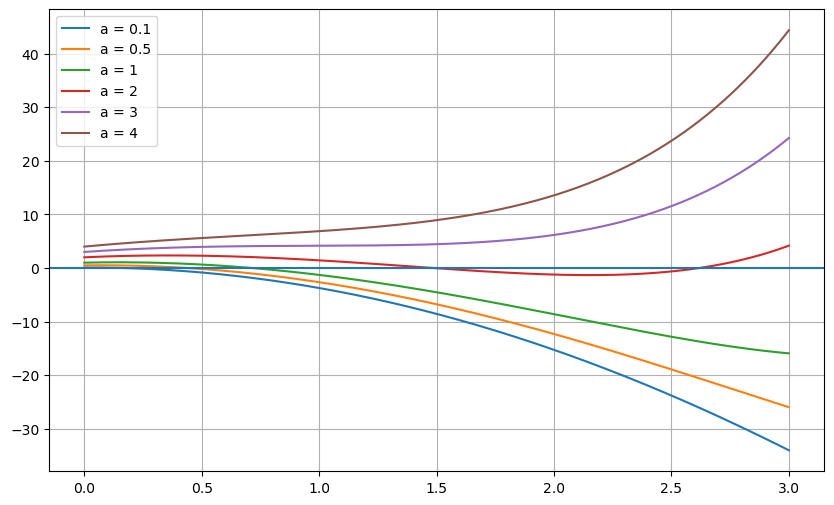

In [8]:
valores_a = [0.1, 0.5, 1, 2, 3, 4]

x = np.linspace(0, 3, 500)

plt.figure(figsize=(10,6))

for a in valores_a:
    funcao = FuncaoMovimento(a)
    plt.plot(x, funcao.f(x), label=f"a = {a}")

plt.axhline(0)
plt.grid()
plt.legend()
plt.show()

Observe:

- Para a = 0.1, 0.5 e 1, a curva cruza o eixo x → existe raiz.
- Para a = 3 e 4, a curva parece ficar sempre acima do eixo x → não existe raiz.
- Para a = 2, acontece algo interessante: a curva cruza o eixo, fica negativa e depois volta a ser positiva, sugerindo duas raízes.

Então parece existir um valor crítico de \(a\) entre 2 e 3.

Descobrindo esse valor matematicamente

Temos:

$$ a e^d - 4d^2 = 0 $$

Isolando \(a\):

$$ a = 4d^2 e^{-d} $$

Agora pense assim:

Para um determinado \(d\), essa fórmula nos diz qual \(a\) gera uma raiz.
Se encontrarmos o maior valor possível de
$$ g(d)=4d^2 e^{-d} $$

teremos o maior valor de \(a\) para o qual ainda existe raiz.

Encontrando o máximo de \(g(d)\)

Derivando:

$$ g(d)=4d^2 e^{-d} $$ $$ g'(d)=8de^{-d}-4d^2e^{-d} $$

Colocando em evidência:

$$ g'(d)=4de^{-d}(2-d) $$

Como \(e^{-d}>0\), temos:

$$ g'(d)=0 $$

quando:

$$ d=0 $$

ou

$$ d=2 $$

O máximo ocorre em:

$$ d=2 $$

Valor máximo

Substituindo \(d=2\):

$$ a_{\max} = 4(2)^2 e^{-2} $$ $$ a_{\max} = 16e^{-2} $$
a
max
	​

≈2.165

Ou seja:

Se
$$ a < 2.165 $$

existem raízes.

Se
$$ a = 2.165 $$

existe uma raiz "limite" (a curva toca o eixo).

Se
$$ a > 2.165 $$

não existe raiz.

Isso bate exatamente com o gráfico:

\(a=2\) → ainda existe raiz.
\(a=3\) → não existe.
\(a=4\) → não existe.

## Comprovando numericamente no notebook

In [9]:
valores_a = [2.0, 2.1, 2.16, 2.17, 2.2]

for a in valores_a:
    funcao = FuncaoMovimento(a)

    x = np.linspace(0, 4, 1000)
    y = funcao.f(x)

    print(
        f"a = {a:.2f}",
        "mínimo =", y.min()
    )

a = 2.00 mínimo = -1.320329680504699
a = 2.10 mínimo = -0.49785249444275337
a = 2.16 mínimo = -0.03973274666758897
a = 2.17 mínimo = 0.03419034665407317
a = 2.20 mínimo = 0.25188781275511474


- Quando o mínimo da função: < 0 -> a curva passou pelo eixo x → existe raiz.

- Quando o mínimo ficar: > 0 -> a curva inteira está acima do eixo → não existe raiz.


## Tabela de análise

In [10]:
valores_a = [0.1, 0.5, 1.0, 1.5, 2.0, 2.1, 2.16, 2.17, 2.2, 2.5, 3.0]

tabelaAnalise = []

for a in valores_a:

    funcao = FuncaoMovimento(a)

    x = np.linspace(0, 4, 1000)

    y = funcao.f(x)

    minimo = y.min()

    existe_raiz = minimo <= 0

    tabelaAnalise.append({
        "a": a,
        "valor_minimo": minimo,
        "existe_raiz": existe_raiz
    })

pd.DataFrame(tabelaAnalise)

,a,valor_minimo,existe_raiz
0,0.10,-58.540185,True
1,0.50,-36.700925,True
2,1.00,-16.460866,True
3,1.50,-6.858972,True
4,2.00,-1.320330,True
5,2.10,-0.497852,True
6,2.16,-0.039733,True
7,2.17,0.034190,False
8,2.20,0.251888,False
9,2.50,2.124229,False


## Conclusão

A função analisada foi:

$$ f(d)=ae^d-4d^2 $$

Para investigar a influência do parâmetro \(a\), realizei testes numéricos para diferentes valores.

Observa-se que existem raízes para valores de \(a\) menores que aproximadamente 2.165.

Quando \(a\) ultrapassa esse valor crítico, a função deixa de cruzar o eixo \(x\), impossibilitando a existência de raízes reais.

Os resultados experimentais mostraram que:

- para \(a=2.16\), ainda existe raiz;
- para \(a=2.17\), não existe raiz.

## Comparação Bisseção x Newton

In [11]:
comparacao = pd.DataFrame({
    "Método": ["Bisseção", "Newton-Raphson"],
    "Raiz": [raiz_bissecao, raiz_newton],
    "Iterações": [
        len(historico_bissecao),
        len(historico_newton)
    ]
})

comparacao

,Método,Raiz,Iterações
0,Bisseção,0.714783,13
1,Newton-Raphson,0.714806,4
